# 实验二：图像灰度变换与直方图均衡化

**实验目的：** 掌握点运算的基本原理，学会利用灰度变换和直方图技术改善图像对比度。
**实验准备：** 请确保在当前目录下有一张名为 `dark_image.jpg` 的偏暗灰度图像。

## 1. 理论基础
图像的灰度变换属于空间域的点运算，常见的数学模型包括：
* **线性对比度拉伸：** 将集中的窄带灰度值拉伸到全范围 $[0, 255]$。
  $$s = \frac{r - r_{min}}{r_{max} - r_{min}} \times 255$$
* **对数变换：** 扩展暗部像素，压缩高光区。
  $$s = c \log(1 + r)$$
* **伽马变换 (Gamma Correction)：** $$s = c r^{\gamma}$$
  当 $\gamma < 1$ 时，提亮暗部；当 $\gamma > 1$ 时，压暗亮部。

图像读取成功！尺寸: (240, 320), 数据类型: uint8


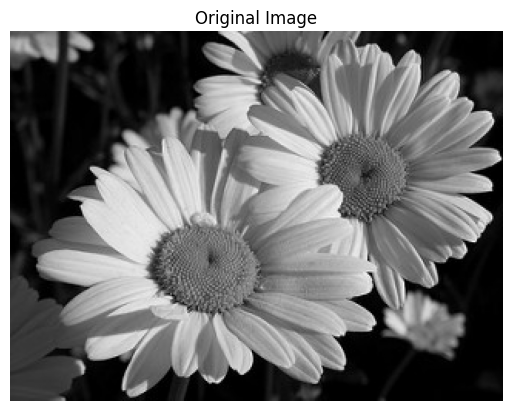

In [6]:
# 导入必要的库
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 使得 Matplotlib 图像直接嵌在 Jupyter Notebook 中显示
%matplotlib inline

# 读取图像 (灰度模式)
img = cv2.imread('dark_image.jpg', cv2.IMREAD_GRAYSCALE)

# 检查图像是否成功读取
if img is None:
    print("错误：找不到 dark_image.jpg，请检查路径！")
else:
    print(f"图像读取成功！尺寸: {img.shape}, 数据类型: {img.dtype}")
    # 简单展示原图
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

## 2. 灰度变换实战
下面我们分别用代码实现线性拉伸、对数变换和伽马变换，来“拯救”这张暗淡的图像。

In [7]:
# 1. 线性对比度拉伸
r_min, r_max = np.min(img), np.max(img)
img_linear = np.uint8(255 * (img - r_min) / (r_max - r_min + 1e-5)) 

# 2. 对数变换
c_log = 255 / np.log(1 + np.max(img))
img_log = np.uint8(c_log * np.log(1 + img.astype(np.float32)))

# 3. 伽马变换 (设定 gamma = 0.5 提升暗部细节)
gamma = 0.5 
img_gamma = np.uint8(np.power(img / 255.0, gamma) * 255.0)

print("灰度变换计算完成！")

灰度变换计算完成！


C:\Users\86177\AppData\Local\Temp\ipykernel_20464\1701750711.py:6: RuntimeWarning: overflow encountered in scalar add
  c_log = 255 / np.log(1 + np.max(img))
C:\Users\86177\AppData\Local\Temp\ipykernel_20464\1701750711.py:6: RuntimeWarning: divide by zero encountered in log
  c_log = 255 / np.log(1 + np.max(img))


## 3. 直方图均衡化 (Histogram Equalization)
除了依靠公式强制转换，我们还可以通过统计图像的**灰度直方图**，让计算机自动均衡像素的分布。
这里我们将对比**全局均衡化**和**限制对比度自适应直方图均衡化 (CLAHE)** 的差异。

In [8]:
# 1. 全局直方图均衡化
img_eq = cv2.equalizeHist(img)

# 2. 自适应直方图均衡化 (CLAHE)
# clipLimit 控制对比度限制，tileGridSize 设定局部计算的网格大小
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img)

print("直方图均衡化计算完成！")

直方图均衡化计算完成！


## 4. 结果可视化与对比分析
使用 `plt.hist(image.ravel())` 可以将二维图像数组展平为一维，并统计每个灰度值（0-255）的像素数量，从而绘制出直方图。

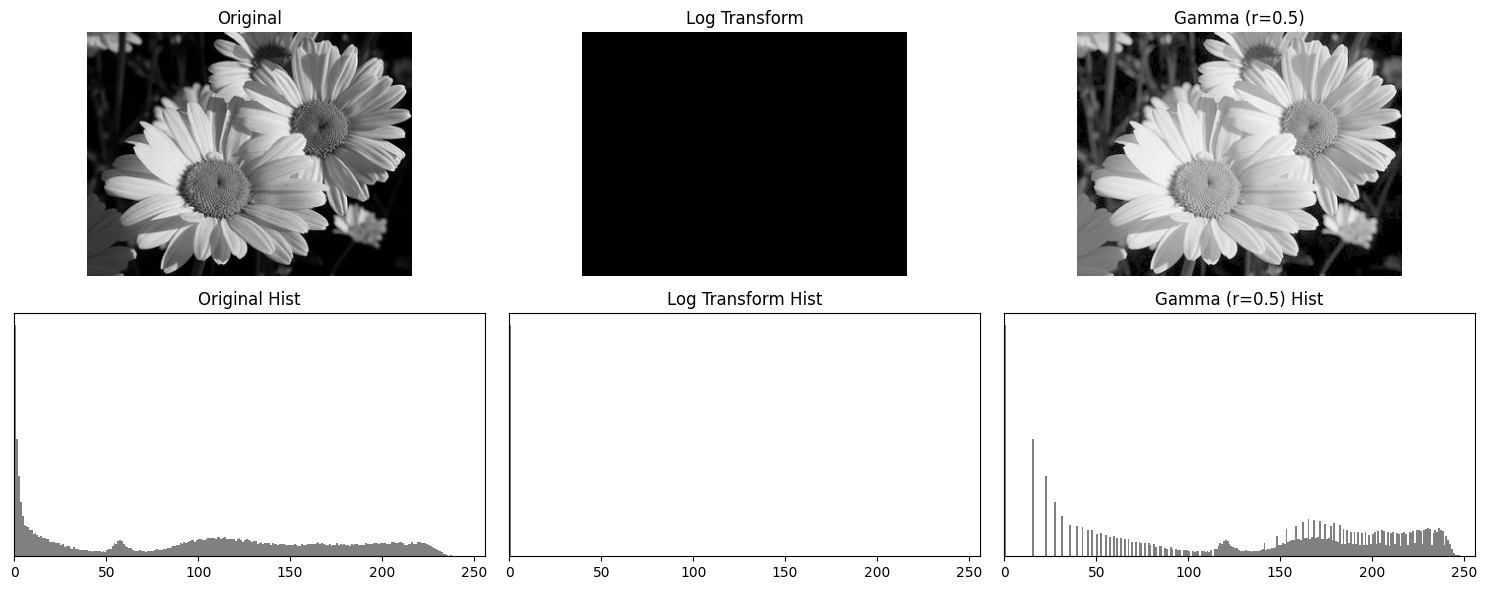

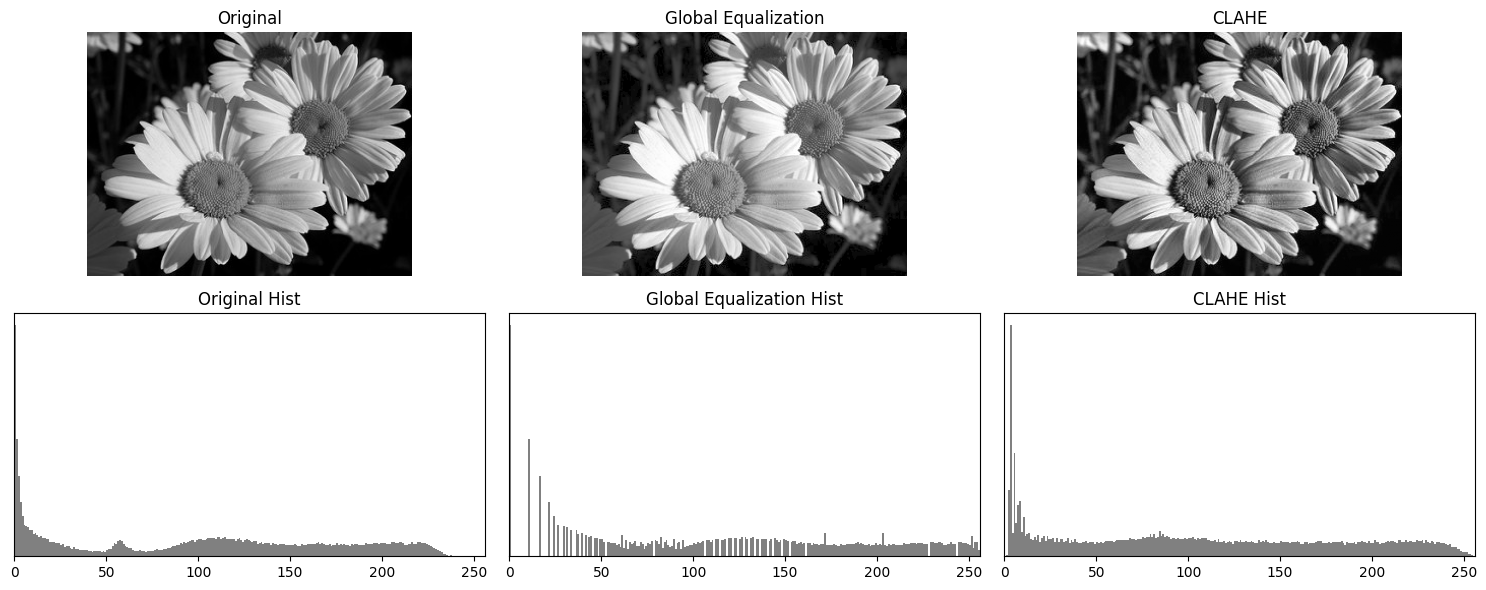

In [9]:
# 定义一个绘图辅助函数，方便同时画出图像和对应的直方图
def plot_img_and_hist(index, image, title, total_cols=3):
    # 画图像
    plt.subplot(2, total_cols, index)
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    
    # 画直方图
    plt.subplot(2, total_cols, index + total_cols)
    plt.hist(image.ravel(), bins=256, range=[0, 256], color='gray')
    plt.title(f"{title} Hist")
    plt.xlim([0, 256])
    # 隐藏直方图的y轴刻度，让画面更清爽
    plt.yticks([]) 

# --- 可视化第一组：灰度变换 ---
plt.figure(figsize=(15, 6))
plot_img_and_hist(1, img, "Original")
plot_img_and_hist(2, img_log, "Log Transform")
plot_img_and_hist(3, img_gamma, f"Gamma (r={gamma})")
plt.tight_layout()
plt.show()

# --- 可视化第二组：均衡化算法 ---
plt.figure(figsize=(15, 6))
plot_img_and_hist(1, img, "Original")
plot_img_and_hist(2, img_eq, "Global Equalization")
plot_img_and_hist(3, img_clahe, "CLAHE")
plt.tight_layout()
plt.show()